In [9]:
import numpy as np
import matplotlib.pyplot as plt
from gaiamock import gaiamock_var  as gm
from gaiamock import variability_tool as vt
import pandas as pd
path_to_data="/Users/giulianoiorio/Dropbox/Work_Project/RRLgaiamock/paper/data/healpix_scans/healpix_scans"
gm.set_healpyx_table_path(path_to_data)

RUWE 0.892390806148088
RUWE 0.9026203233127463


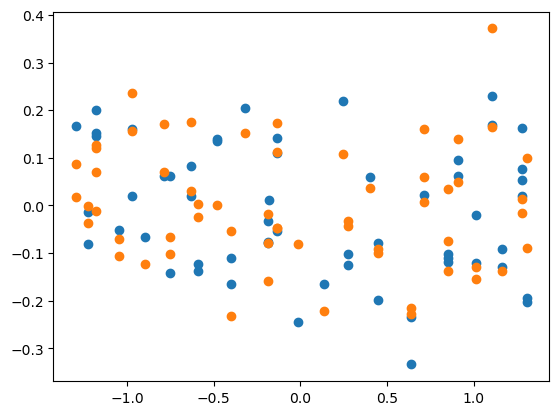

In [7]:
ra=230
dec=35
pmra=0
pmdec=0
parallax=0.2
phot_g_mean_mag=15

#JDB_TCB = t_gaia + 2455197.5

t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

varmodel=vt.SimpleSinusoidal(amp=0.8,period=1,fchrom=0.2)
t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    variability_tool=varmodel
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

In [10]:
#Realistic RRL from Gaia

class LCtemplate:
    def __init__(self, zp_mag, A, Phi, narm, reference_time,period):

        self.zp_mag = zp_mag
        self.narm = narm
        self.A    = A[:narm]
        self.Phi  = Phi[:narm]
        self.reference_time = reference_time
        self.period = period

        self.iarm = np.arange(1,narm+1)

    def lc(self,x,folded=False):

        if folded:
            phase=x
        else:
            phase=(t-self.reference_time)/self.period 
        
        return self.zp_mag + np.sum([ self.A[i]*np.cos(2*np.pi*self.iarm[i]*phase+self.Phi[i]) for i in range(self.narm) ],axis=0)
        

    def lc_der(self,x,folded=False):

        if folded:
            phase=x
            dmod_dx = 2*np.pi*self.iarm
        else:
            phase=(t-self.reference_time)/self.period 
            dmod_dx = 2*np.pi*self.iarm/self.period
            
        return np.sum([ -self.A[i]*dmod_dx[i]*np.sin(2*np.pi*self.iarm[i]*phase+self.Phi[i]) for i in range(self.narm) ],axis=0)
    

class RRLVariable(vt.VariabilityTool):

    def __init__(self,gaiadf,fchrom):
        super().__init__(fchrom=fchrom)

        string_to_array = lambda st: np.array([float(x) for x in st[1:-1].split(",")])

        self.LCtemplate_bp = self.reconstruct_lc(gaiadf,band="bp")
        self.LCtemplate_rp = self.reconstruct_lc(gaiadf,band="rp")
        

    def __call__(self, time):
        #Transform 
        return self.LCtemplate_bp.lc(time)  - self.LCtemplate_rp.lc(time)
    
    @staticmethod
    def reconstruct_lc(df,band="g"):
        """
        In Gaia SOS the RRL light curve are fitted with a Fourier series as
        G(t) = zp + Sum A_i cos(2pi i nu_max (t-tref) + Phi_i)
        where zp is the zero poing magnitude, A_i and Phi_i are the amplitude 
        of the armonics, with nu_max the frequencey of the fundamental one with nu_max=1/Period
        """
        zp_mag = df[f"zp_mag_{band}"].values #zero point for the Fourier curve decomposition
        numax=df["fund_freq1"].values #numax (1/Period)
        narm=df[f"num_harmonics_for_p1_{band}"].values[0]
        reference_time = df[f"reference_time_{band}"].values[0] #Reference time for the fourier curve decomposition
        Ai=string_to_array(df[f"fund_freq1_harmonic_ampl_{band}"].values[0])[:narm]
        Phii=string_to_array(df[f"fund_freq1_harmonic_phase_{band}"].values[0])[:narm]
        iarm = np.arange(1,narm+1)
    
        return LCtemplate(zp_mag=zp_mag, A=Ai, Phi=Phii, narm=narm, reference_time=reference_time, period=1/numax)

datadf=pd.read_parquet("/Users/giulianoiorio/Dropbox/Work_Project/RRLgaiamock/data/RRL/RL_G3_kine_reduced_wIB21_extramet_cleaned_highmet.parquet")

In [13]:
datadf["fund_freq1"]

KeyError: 'fund_freq1'

In [15]:
print(*datadf.columns)

source_id ra dec parallax parallax_error pmra pmra_error pmdec pmdec_error ruwe phot_g_n_obs phot_g_mean_mag phot_bp_n_obs phot_bp_mean_mag phot_rp_n_obs phot_rp_mean_mag phot_bp_rp_excess_factor bp_rp radial_velocity radial_velocity_error l b non_single_star pf pf_error p1_o p1_o_error int_average_g int_average_g_error int_average_bp int_average_bp_error int_average_rp int_average_rp_error average_rv average_rv_error peak_to_peak_g peak_to_peak_g_error peak_to_peak_bp peak_to_peak_bp_error peak_to_peak_rp peak_to_peak_rp_error peak_to_peak_rv peak_to_peak_rv_error metallicity metallicity_error r21_g r21_g_error r31_g r31_g_error phi21_g phi21_g_error phi31_g phi31_g_error reference_time_g reference_time_bp reference_time_rp reference_time_rv best_classification g_absorption g_absorption_error ebv x y z x_err y_err z_err p_x_y p_x_z p_y_z Rcyl phi Rcyl_err phi_err p_Rcyl_phi p_Rcyl_z p_phi_z r theta r_err theta_err p_r_theta p_r_phi p_theta_phi pmra_c pmdec_c pml pmb pml_c pmb_c Vl Vb 